Integración y análisis final.

C:\Users\aguir\AppData\Local\Temp\ipykernel_26484\1751541601.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=feature_df, palette='viridis')


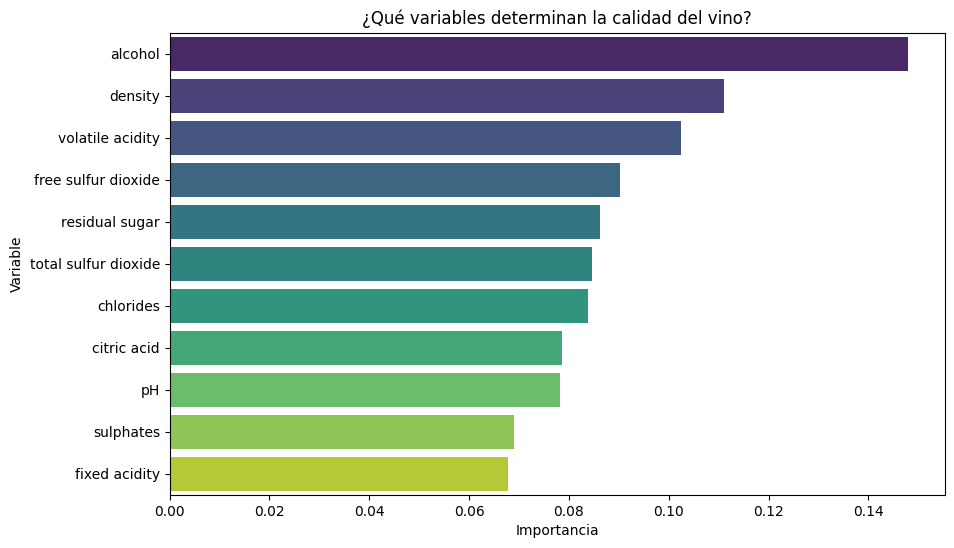

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import os

# Configuración de rutas e importación de tu función de carga
sys.path.append(os.path.abspath(".."))
from src.data_preprocessing import load_data

# Cargar los datos para obtener los nombres de las columnas
# (Asegúrate de que la ruta sea correcta según tu carpeta)
df_raw = load_data("../data/winequality-white.csv")

# Cargar el modelo final entrenado
model = joblib.load('../models/trained_models/final_optimized_rf_model.pkl')

# Extraer importancia
importancias = model.feature_importances_
nombres_columnas = df_raw.drop('quality', axis=1).columns

# Crear DataFrame y graficar
feature_df = pd.DataFrame({'Variable': nombres_columnas, 'Importancia': importancias})
feature_df = feature_df.sort_values(by='Importancia', ascending=False)

# Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=feature_df, palette='viridis')
plt.title('¿Qué variables determinan la calidad del vino?')

# OPCIONAL: Guardar el gráfico automáticamente en tu carpeta de resultados
os.makedirs('../results/plots/', exist_ok=True)
plt.savefig('../results/plots/feature_importance.png')

plt.show()